# Pythia EFP Covariance

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import energyflow as ef
from energyflow.utils import gen_massless_phase_space
from energyflow import EFPSet
import os
from RegressFunctions import *

os.makedirs('figures', exist_ok=True)

# Load Pythia Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [2]:
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events

Zqq_events = load_events('data/Zqq_events.txt')
Hgg_events = load_events('data/Hgg_events.txt')


mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')

Z->qqbar: 100000 events, avg multiplicity 12.4 +/- 4.2
H->gg:    100000 events, avg multiplicity 19.9 +/- 5.2


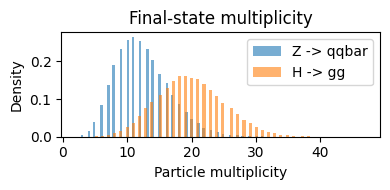

In [3]:
# Quick sanity check: plot multiplicity distributions
fig, ax = plt.subplots(figsize=(4, 2))
ax.hist(mults_Z, bins=90, alpha=0.6, label='Z -> qqbar', density=True)
ax.hist(mults_H, bins=90, alpha=0.6, label='H -> gg', density=True)
ax.set_xlabel('Particle multiplicity')
ax.set_ylabel('Density')
ax.set_title('Final-state multiplicity')
ax.legend()
plt.tight_layout()
plt.show()

# Uniform Phase Space

In [4]:
NEvents=100_000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N9 = gen_massless_phase_space(NEvents,9,energy=1.0)

# efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

()

# Plot some Kinematics

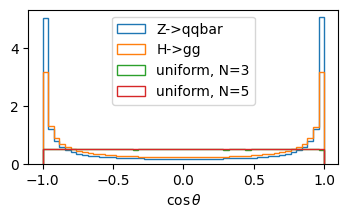

In [5]:
cos_theta_Z  = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in Zqq_events])
cos_theta_H  = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in Hgg_events])
cos_theta_u3 = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in uniform_N3])
cos_theta_u5 = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in uniform_N5])

fig, ax = plt.subplots(figsize=(4, 2))
plt.hist(cos_theta_Z, bins=50, alpha=1, density=True, histtype='step', label='Z->qqbar')
plt.hist(cos_theta_H, bins=50, alpha=1, density=True, histtype='step', label='H->gg')
plt.hist(cos_theta_u3, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=3')
plt.hist(cos_theta_u5, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=5')
plt.xlabel(r'$\cos\theta$'); 
plt.legend(); 
plt.show()

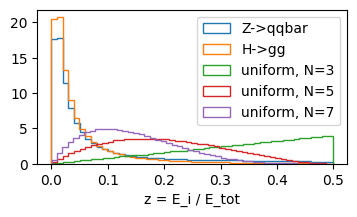

In [6]:
z_Z  = np.concatenate([e[:, 0] / e[:, 0].sum() for e in Zqq_events])
z_H  = np.concatenate([e[:, 0] / e[:, 0].sum() for e in Hgg_events])
z_u3 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N3])
z_u5 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N5])
z_u7 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N7])

fig, ax = plt.subplots(figsize=(4, 2))
plt.hist(z_Z, bins=50, alpha=1, density=True, histtype='step', label='Z->qqbar')
plt.hist(z_H, bins=50, alpha=1, density=True, histtype='step', label='H->gg')
plt.hist(z_u3, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=3')
plt.hist(z_u5, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=5')
plt.hist(z_u7, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=7')

plt.xlabel('z = E_i / E_tot'); 
plt.legend(); 
plt.show()


# Compute EFPs

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [7]:
efpset = ef.EFPSet(('d<=', 5),  measure='eeefm', beta=2, normed=True, coords='epxpypz')
print(f'EFP basis: {efpset.count()} EFPs')

EFPs_N3 = efpset.batch_compute(uniform_N3);   print('uniform N=3 done')
EFPs_N5 = efpset.batch_compute(uniform_N5);   print('uniform N=5 done')
EFPs_N7 = efpset.batch_compute(uniform_N7);   print('uniform N=7 done')
EFPs_N9 = efpset.batch_compute(uniform_N9);   print('uniform N=9 done')

EFPs_Zqq = efpset.batch_compute(Zqq_events); print('Z->qqbar done')
EFPs_Hgg = efpset.batch_compute(Hgg_events); print('H->gg done')


EFP basis: 102 EFPs
uniform N=3 done
uniform N=5 done
uniform N=7 done
uniform N=9 done
Z->qqbar done
H->gg done


In [43]:
# efpset_d4Beta1 = ef.EFPSet('d<=4', measure='ee', beta=1, normed=True)
# efpset_d4Beta2 = ef.EFPSet('d<=4', measure='ee', beta=2, normed=True)
# efpset_d5Beta1 = ef.EFPSet('d<=5', measure='ee', beta=1, normed=True)
# efpset_d5Beta2 = ef.EFPSet('d<=5', measure='ee', beta=2, normed=True)

# configs = [
#     ('d4b1', efpset_d4Beta1, r'$d_{\leq 4},\ \beta=1$'),
#     ('d4b2', efpset_d4Beta2, r'$d_{\leq 4},\ \beta=2$'),
#     ('d5b1', efpset_d5Beta1, r'$d_{\leq 5},\ \beta=1$'),
#     ('d5b2', efpset_d5Beta2, r'$d_{\leq 5},\ \beta=2$'),
# ]

# efps_all = {}
# for key, efpset, label in configs:
#     Z = efpset.batch_compute(Zqq_events)
#     H = efpset.batch_compute(Hgg_events)
#     efps_all[key] = {'Z': Z, 'H': H, 'label': label}
#     print(f'{key}: n_EFPs={Z.shape[1]}')

In [8]:
# Log
eps = 1e-10
log_EFPs_Zqq = np.log(EFPs_Zqq + eps)
log_EFPs_Hgg = np.log(EFPs_Hgg + eps)
log_EFPs_N3  = np.log(EFPs_N3  + eps)
log_EFPs_N5  = np.log(EFPs_N5  + eps)
log_EFPs_N7  = np.log(EFPs_N7  + eps)
log_EFPs_N9  = np.log(EFPs_N9  + eps)


## Covariance Matrix

In [9]:
cov_u3 = np.cov(EFPs_N3.T)
cov_u5 = np.cov(EFPs_N5.T)
cov_u7 = np.cov(EFPs_N7.T)
cov_u9 = np.cov(EFPs_N9.T)

cov_Z = np.cov(EFPs_Zqq.T) 
cov_H = np.cov(EFPs_Hgg.T)
print(f'Covariance matrix shape: {cov_Z.shape}')

Covariance matrix shape: (102, 102)


## Eigenspectrum

Diagonalize each covariance matrix and plot eigenvalues sorted in descending order.
The shape of this spectrum reflects how correlated the EFPs are — a steep drop means
most variance is captured by the first few eigenvectors.

In [10]:
samples = [('Z->qqbar', cov_Z), ('H->gg', cov_H),
           ('uniform N=3', cov_u3), ('uniform N=5', cov_u5),
           ('uniform N=7', cov_u7), ('uniform N=9', cov_u9)]

eigvals = {}
for name, cov in samples:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

Z->qqbar: largest = 1.5153e+04, smallest = 0.0000e+00
H->gg: largest = 1.6432e+04, smallest = 0.0000e+00
uniform N=3: largest = 2.2945e+04, smallest = 0.0000e+00
uniform N=5: largest = 1.0293e+04, smallest = 0.0000e+00
uniform N=7: largest = 5.2481e+03, smallest = 0.0000e+00
uniform N=9: largest = 3.1805e+03, smallest = 0.0000e+00


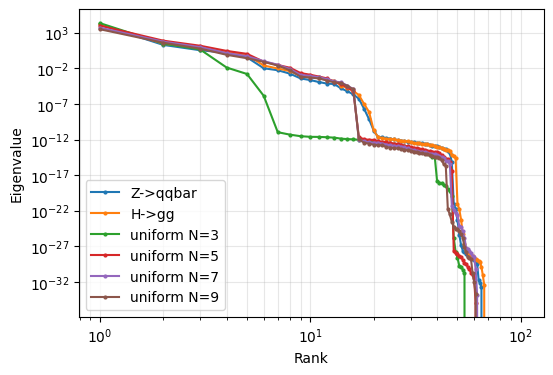

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=4, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.grid(True, which='both', alpha=0.3)

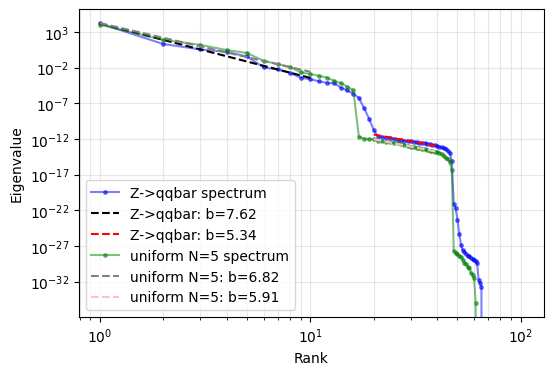

In [12]:
fit_min, fit_max = 1, 10
fit_min2, fit_max2 = 20, 40

fig, ax = plt.subplots(figsize=(6, 4))
for name, color0, color1, color2 in [('Z->qqbar', 'b', 'k','r'), 
                    # ('H->gg', 'r'), 
                    ('uniform N=5', 'g', 'gray', 'pink')]:
    ev = eigvals[name]
    idx = np.arange(1, len(ev)+1)
    ax.loglog(idx, ev, '.-', markersize=5, color=color0, label=f'{name} spectrum', alpha=0.5)
    mask = (idx >= fit_min) & (idx <= fit_max) & (ev > 0)
    mask2 = (idx >= fit_min2) & (idx <= fit_max2) & (ev > 0)
    slope, log_c = np.polyfit(np.log(idx[mask]), np.log(ev[mask]), 1)
    slope2, log_c2 = np.polyfit(np.log(idx[mask2]), np.log(ev[mask2]), 1)
    ax.loglog(idx[mask], np.exp(log_c)*idx[mask]**slope, '--', color=color1,
              label=f'{name}: b={-slope:.2f}', alpha=1)
    ax.loglog(idx[mask2], np.exp(log_c2)*idx[mask2]**slope2, '--', color=color2,
              label=f'{name}: b={-slope2:.2f}', alpha=1)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.grid(True, which='both', alpha=0.3)

In [64]:
# _, U_Z = np.linalg.eigh(cov_Z)
# _, U_N5 = np.linalg.eigh(cov_u5)
# overlap = np.abs(U_Z.T @ U_N5)  # shape (102, 102)
# plt.imshow(overlap, vmin=0, vmax=1, cmap='hot')
# plt.colorbar(); plt.title('|eigvec overlap| Z vs uniform N=5')
# plt.show()


## Linear Regression: EFPs → Quark/Gluon Label

Combine both samples with labels 0 (Z→qqbar) and 1 (H→gg). Train linear regression on
subsets of increasing size and plot test loss vs number of training events.

In [13]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine log EFPs and labels
X = np.vstack([EFPs_Zqq, EFPs_Hgg])
y = np.array([0] * len(EFPs_Zqq) + [1] * len(EFPs_Hgg), dtype=float)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

X_test, y_test   = X[-20000:], y[-20000:]
X_train, y_train = X[:-20000], y[:-20000]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fixed ridge penalty r — RidgeCV selects r optimal for large N,
# which is too small for small-N subsets and causes instability.
# r = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5).fit(X_train_s, y_train).alpha_
r = 1e-2
print(f'Fixed ridge r = {r:.4e}')

train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000]
train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000, 15000, 30000, 60000, 120000, 160000]
test_losses = []
n_repeats = 500

print("Train size | Test MSE (avg over repeats)")
for n in train_sizes:
    losses_n = []
    for seed in range(n_repeats):
        sub_idx = np.random.default_rng(seed).choice(len(X_train_s), size=n, replace=False)
        reg = Ridge(alpha=r).fit(X_train_s[sub_idx], y_train[sub_idx])
        losses_n.append(mean_squared_error(y_test, reg.predict(X_test_s)))
    mean_loss = np.mean(losses_n)
    test_losses.append(mean_loss)
    print(f"  {n:6d}   |  {mean_loss:.6f}")

Fixed ridge r = 1.0000e-02
Train size | Test MSE (avg over repeats)
       5   |  0.780936
       8   |  0.553151
      10   |  0.468198
      15   |  0.316864
      25   |  0.232229
      50   |  0.188709
      75   |  0.177528
     100   |  0.172183
     150   |  0.167489
     200   |  0.164680
     300   |  0.161892
     500   |  0.159092
     700   |  0.157589
    1000   |  0.156041
    1500   |  0.154678
    2000   |  0.153846
    3000   |  0.152968
    5000   |  0.152200
    8000   |  0.151734
   15000   |  0.151377
   30000   |  0.151150
   60000   |  0.151002
  120000   |  0.150868
  160000   |  0.150813


Estimated irreducible floor: 0.150813


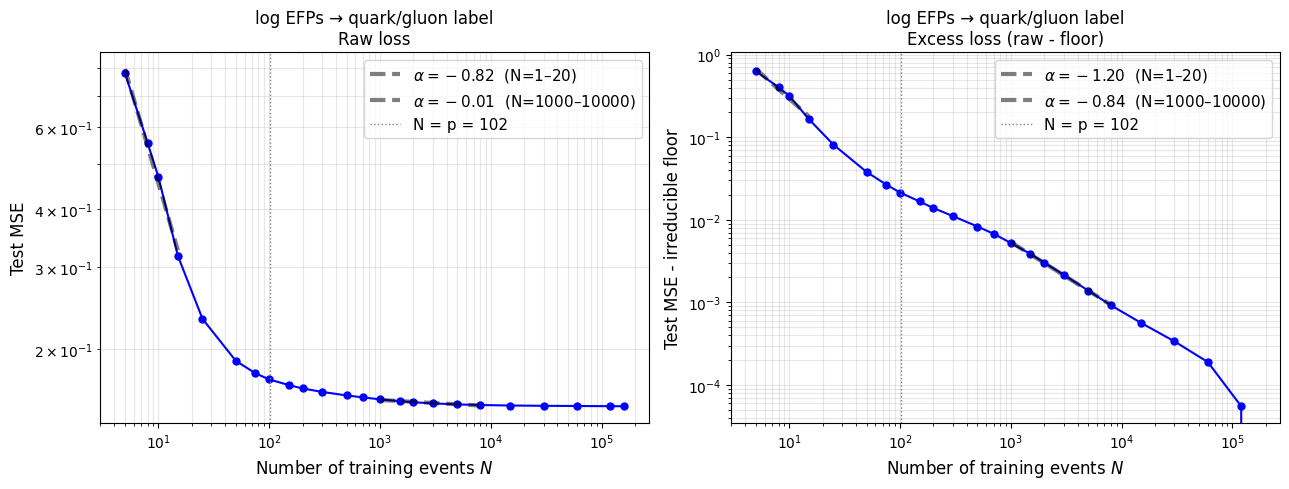

In [14]:
fit_n_min_1 = 1
fit_n_max_1 = 20

fit_n_min_2 = 1000
fit_n_max_2 = 10000

floor = test_losses[-1]
excess_losses = [l - floor for l in test_losses]
print(f'Estimated irreducible floor: {floor:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, losses, title, ylabel, exclude_last in zip(
    axes,
    [test_losses, excess_losses],
    ['Raw loss', 'Excess loss (raw - floor)'],
    ['Test MSE', 'Test MSE - irreducible floor'],
    [False, True]
):
    ax.loglog(train_sizes, losses, 'bo-', markersize=5)

    ns_all = train_sizes[:-1] if exclude_last else train_sizes
    ls_all = losses[:-1]      if exclude_last else losses

    mask_1 = [fit_n_min_1 <= n <= fit_n_max_1 for n in ns_all]
    ns_fit_1 = [n for n, m in zip(ns_all, mask_1) if m]
    ls_fit_1 = [l for l, m in zip(ls_all, mask_1) if m]

    mask_2 = [fit_n_min_2 <= n <= fit_n_max_2 for n in ns_all]
    ns_fit_2 = [n for n, m in zip(ns_all, mask_2) if m]
    ls_fit_2 = [l for l, m in zip(ls_all, mask_2) if m]

    if len(ns_fit_1) >= 2:
        slope_1, log_c_1 = np.polyfit(np.log(ns_fit_1), np.log(ls_fit_1), 1)
        ax.loglog(ns_fit_1, np.exp(log_c_1) * np.array(ns_fit_1)**slope_1, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_1:.2f}$  (N={fit_n_min_1}–{fit_n_max_1})')
        
    if len(ns_fit_2) >= 2:
        slope_2, log_c_2 = np.polyfit(np.log(ns_fit_2), np.log(ls_fit_2), 1)
        ax.loglog(ns_fit_2, np.exp(log_c_2) * np.array(ns_fit_2)**slope_2, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_2:.2f}$  (N={fit_n_min_2}–{fit_n_max_2})')

    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p = 102')
    ax.set_xlabel('Number of training events $N$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'log EFPs → quark/gluon label\n{title}', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scaling_law_label.png', dpi=150, bbox_inches='tight')
plt.show()

## Linear Regression: EFPs → Thrust

Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [15]:
def compute_thrust(event):
    """Thrust for an e+e- event. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                      # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)      # |\vec{p}|
    momenta = momenta[norms > 1e-10]             # get rid of 
    norms = norms[norms > 1e-10]                 # particles with 0 norm ... 
    denom = np.sum(norms)                        # sum_i |p_i| 
    best_T = 0.
    for i in range(len(momenta)):                  # only scanning over momenta in the event ...  
        n = momenta[i] / norms[i]                  # \hat{p}
        T = np.sum(np.abs(momenta @ n)) / denom    # sum_i |  |
        if T > best_T:
            best_T = T
    return best_T


def compute_thrust_iterative(event, max_iter=20):
    """Exact thrust via iterated hemisphere refinement. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                        # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)        # |\vec{p}|
    momenta = momenta[norms > 1e-10]
    norms = norms[norms > 1e-10]
    denom = np.sum(norms)     
    best_T = 0.
    for i in range(len(momenta)):
        n = momenta[i] / norms[i]
        for _ in range(max_iter):
            signs = np.sign(momenta @ n)       # assigns each momenta to a hemisphere +/-
            signs[signs == 0] = 1.
            n_new = signs @ momenta            # optimal axis is sum of momenta on + hemisphere
            norm_new = np.linalg.norm(n_new) 
            if norm_new < 1e-10:
                break
            n_new /= norm_new
            if np.abs(1. - np.abs(n_new @ n)) < 1e-12:  # check convergence
                break
            n = n_new
        T = np.sum(np.abs(momenta @ n)) / denom
        if T > best_T:
            best_T = T
    return best_T

In [16]:
thrust_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=9': uniform_N9,
}

thrusts = {}
for name, events in thrust_samples.items():
    t = np.array([compute_thrust(e) for e in events])
    thrusts[name] = t
    print(f'{name}: mean thrust = {np.mean(t):.4f} +/- {np.std(t):.4f}')


Z->qqbar: mean thrust = 0.9351 +/- 0.0631
H->gg: mean thrust = 0.8612 +/- 0.0826
uniform N=3: mean thrust = 0.8888 +/- 0.0786
uniform N=5: mean thrust = 0.7699 +/- 0.0881
uniform N=7: mean thrust = 0.7212 +/- 0.0777
uniform N=9: mean thrust = 0.6955 +/- 0.0691


In [17]:
# # def ridge_predict_torch(X_train, y_train, X_test, r=1e-8):
# #     X = torch.tensor(X_train, dtype=torch.float64)
# #     y = torch.tensor(y_train, dtype=torch.float64)
# #     XtX = X.T @ X + r * torch.eye(X.shape[1], dtype=torch.float64)
# #     Xty = X.T @ y
# #     w = torch.linalg.solve(XtX, Xty)
# #     return (torch.tensor(X_test, dtype=torch.float64) @ w).numpy()

# def ridge_predict_torch(X_train, y_train, X_test, r=1e-8):
#     X = torch.tensor(X_train, dtype=torch.float64)
#     y = torch.tensor(y_train, dtype=torch.float64)
#     y_mean = y.mean()
#     y = y - y_mean
#     XtX = X.T @ X + r * torch.eye(X.shape[1], dtype=torch.float64)
#     w = torch.linalg.solve(XtX, X.T @ y)
#     return (torch.tensor(X_test, dtype=torch.float64) @ w + y_mean).numpy()


# # def ridge_predict_torch(X_train, y_train, X_test, r=1e-8):
# #     X = torch.tensor(X_train, dtype=torch.float64)
# #     y = torch.tensor(y_train, dtype=torch.float64)
# #     y_mean = y.mean()
# #     y = y - y_mean
# #     n, p = X.shape
# #     if n < p:
# #         K = X @ X.T + r * torch.eye(n, dtype=torch.float64)
# #         alpha = torch.linalg.solve(K, y)
# #         w = X.T @ alpha
# #     else:
# #         w = torch.linalg.solve(X.T @ X + r * torch.eye(p, dtype=torch.float64), X.T @ y)
# #     return (torch.tensor(X_test, dtype=torch.float64) @ w + y_mean).numpy()



# def run_thrust_regression(X, y, train_sizes, r=1e-8, n_repeats=500, test_size=20000):
#     X, y = np.array(X), np.array(y)
#     idx = np.random.default_rng(42).permutation(len(X))
#     X, y = X[idx], y[idx]
#     X_test, y_test   = X[-test_size:], y[-test_size:]
#     X_train, y_train = X[:-test_size], y[:-test_size]
#     scaler = StandardScaler()
#     X_train_s = scaler.fit_transform(X_train)
#     X_test_s  = scaler.transform(X_test)
#     losses = []
#     for n in train_sizes:
#         ls = []
#         for s in range(n_repeats):
#             sub_idx = np.random.default_rng(s).choice(len(X_train_s), n, replace=False)
#             y_pred = ridge_predict_torch(X_train_s[sub_idx], y_train[sub_idx], X_test_s, r)
#             ls.append(mean_squared_error(y_test, y_pred))
#         losses.append(np.mean(ls))
#         print(f'  {n:6d}  |  {losses[-1]:.6f}')
#     return losses


# def run_thrust_regression_sklearn(X, y, train_sizes, r=1e-8, n_repeats=500, test_size=20000):
#     X, y = np.array(X), np.array(y)
#     idx = np.random.default_rng(42).permutation(len(X))
#     X, y = X[idx], y[idx]
#     X_test, y_test   = X[-test_size:], y[-test_size:]
#     X_train, y_train = X[:-test_size], y[:-test_size]
#     scaler = StandardScaler()
#     X_train_s = scaler.fit_transform(X_train)
#     X_test_s  = scaler.transform(X_test)
#     losses = []
#     for n in train_sizes:
#         ls = []
#         for s in range(n_repeats):
#             sub_idx = np.random.default_rng(s).choice(len(X_train_s), n, replace=False)
#             reg = Ridge(alpha=r).fit(X_train_s[sub_idx], y_train[sub_idx])
#             ls.append(mean_squared_error(y_test, reg.predict(X_test_s)))
#         losses.append(np.mean(ls))
#         print(f'  {n:6d}  |  {losses[-1]:.6f}')
#     return losses


In [18]:
# Check sklearn vs Torch

# X_san, y_san = np.array(EFPs_Zqq), np.array(thrusts['Z->qqbar'])
# idx = np.random.default_rng(42).permutation(len(X_san))
# X_san, y_san = X_san[idx], y_san[idx]
# scaler_san = StandardScaler()
# X_tr = scaler_san.fit_transform(X_san[:-20000])
# X_te = scaler_san.transform(X_san[-20000:])
# y_tr, y_te = y_san[:-20000], y_san[-20000:]

# sub_idx = np.random.default_rng(0).choice(len(X_tr), 5, replace=False)
# y_pred_torch = ridge_predict_torch(X_tr[sub_idx], y_tr[sub_idx], X_te, 1e-8)
# y_pred_sk = Ridge(alpha=1e-8).fit(X_tr[sub_idx], y_tr[sub_idx]).predict(X_te)

# print('torch  MSE:', mean_squared_error(y_te, y_pred_torch))
# print('sklearn MSE:', mean_squared_error(y_te, y_pred_sk))


In [20]:
print(len(EFPs_Zqq))
train_sizes_t = [5, 10, 25, 50, 100, 300, 500, 1000, 3000, 5000, 7000, 9000, 10000, 20000, 40000, 60000, 80000]
losses_Z  = run_torch_regression(EFPs_Zqq, thrusts['Z->qqbar'],    train_sizes_t, r=1e-8)
losses_N5 = run_torch_regression(EFPs_N5,  thrusts['uniform N=5'], train_sizes_t, r=1e-8)

losses_Z_sk  = run_sklearn_regression(EFPs_Zqq, thrusts['Z->qqbar'],    train_sizes_t, r=1e-8)
losses_N5_sk = run_sklearn_regression(EFPs_N5,  thrusts['uniform N=5'], train_sizes_t, r=1e-8)


100000
       5  |  0.022123
      10  |  0.008260
      25  |  0.003421
      50  |  0.001673
     100  |  0.000398
     300  |  0.000071
     500  |  0.000048
    1000  |  0.000038
    3000  |  0.000031
    5000  |  0.000030
    7000  |  0.000030
    9000  |  0.000030
   10000  |  0.000030
   20000  |  0.000029
   40000  |  0.000029
   60000  |  0.000029
   80000  |  0.000029
       5  |  0.019033
      10  |  0.008626
      25  |  0.002481
      50  |  0.000808
     100  |  0.000478
     300  |  0.000351
     500  |  0.000331
    1000  |  0.000315
    3000  |  0.000306
    5000  |  0.000304
    7000  |  0.000303
    9000  |  0.000303
   10000  |  0.000303
   20000  |  0.000302
   40000  |  0.000302
   60000  |  0.000302
   80000  |  0.000301
       5  |  0.003233
      10  |  0.001994
      25  |  0.000608
      50  |  0.000274
     100  |  0.000105
     300  |  0.000045
     500  |  0.000038
    1000  |  0.000033
    3000  |  0.000030
    5000  |  0.000030
    7000  |  0.000029
   

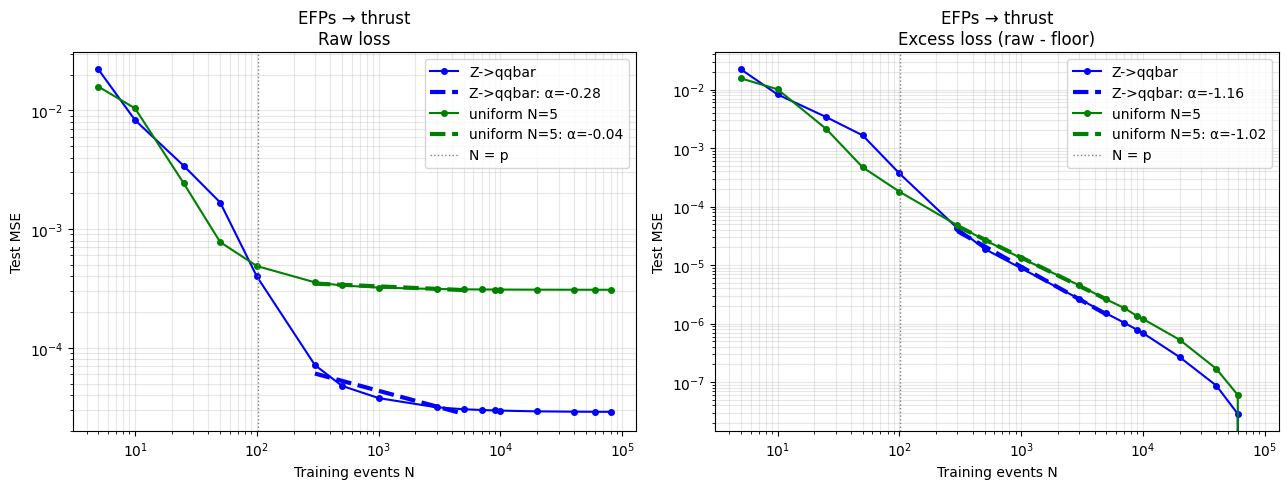

In [188]:
fit_min, fit_max = 200, 5000

all_results = {
    'Z->qqbar':    losses_Z,
    'uniform N=5': losses_N5,
}
colors = {'Z->qqbar': 'b', 'uniform N=5': 'g'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'EFPs → thrust\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

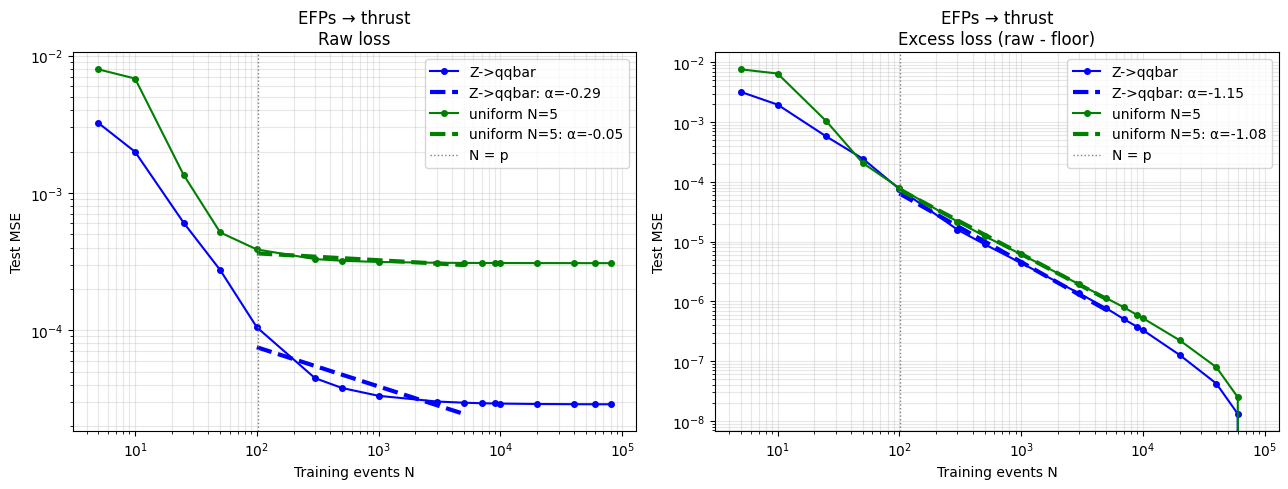

In [189]:
fit_min, fit_max = 100, 5000

all_results = {
    'Z->qqbar':    losses_Z_sk,
    'uniform N=5': losses_N5_sk,
}
colors = {'Z->qqbar': 'b', 'uniform N=5': 'g'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'EFPs → thrust\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

## Linear Regression: EFPs → C-parameter

In [191]:
def compute_C_parameter(event):
    momenta = event[:, 1:4]
    norms = np.linalg.norm(momenta, axis=1)
    momenta = momenta[norms > 1e-10]
    norms = norms[norms > 1e-10]
    denom = np.sum(norms)
    Theta = np.einsum('ki,kj->ij', momenta, momenta) / (denom**2)
    eigvals = np.linalg.eigvalsh(Theta)
    l1, l2, l3 = np.sort(eigvals)
    return 3 * (l1*l2 + l2*l3 + l1*l3)


In [192]:
Cparam_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=9': uniform_N9,
}

Cparams = {}
for name, events in Cparam_samples.items():
    t = np.array([compute_C_parameter(e) for e in events])
    Cparams[name] = t
    print(f'{name}: mean C-param = {np.mean(t):.4f} +/- {np.std(t):.4f}')

Z->qqbar: mean C-param = 0.0034 +/- 0.0040
H->gg: mean C-param = 0.0042 +/- 0.0039
uniform N=3: mean C-param = 0.0375 +/- 0.0246
uniform N=5: mean C-param = 0.0322 +/- 0.0099
uniform N=7: mean C-param = 0.0223 +/- 0.0053
uniform N=9: mean C-param = 0.0159 +/- 0.0035


In [45]:
# Whitener
def compute_whitener(cov_ref, rcond=1e-10):
    """PCA-whitening map from a reference covariance.
    Returns W (p x r) with W.T @ cov_ref @ W = I_r."""
    w, U = np.linalg.eigh(cov_ref)
    w, U = w[::-1], U[:, ::-1]
    keep = w > rcond * w[0]
    Ur, wr = U[:, keep], w[keep]
    W = Ur / np.sqrt(wr)
    return W, keep
def whiten_cov(cov, W):
    """Express a covariance in the uniform-whitened basis: r x r."""
    return W.T @ cov @ W

r = 32 directions kept out of 314


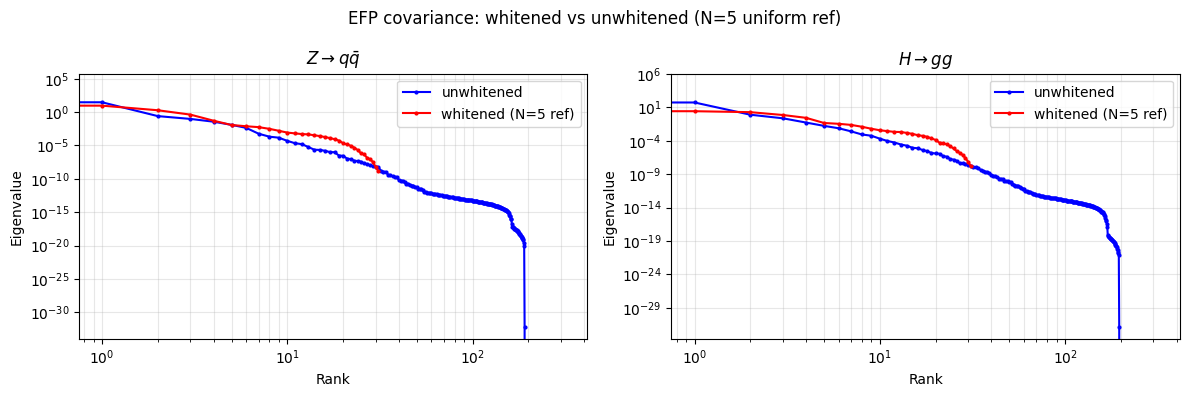

In [46]:
# Whitener from N=5 uniform phase space
W_N5, keep_N5 = compute_whitener(EFP_cov_N5)
print(f'r = {W_N5.shape[1]} directions kept out of {W_N5.shape[0]}')

# Raw Pythia EFP covariances — must use same efpset as section 7 for consistent dimensions
EFPs_Z_raw = efpset.batch_compute(Zqq_events)
EFPs_H_raw = efpset.batch_compute(Hgg_events)
cov_Z_raw  = np.cov(EFPs_Z_raw.T)
cov_H_raw  = np.cov(EFPs_H_raw.T)

# Whitened covariances: W^T C W
cov_Z_white = W_N5.T @ cov_Z_raw @ W_N5
cov_H_white = W_N5.T @ cov_H_raw @ W_N5

# Eigenspectra
eigs_Z_raw   = np.clip(np.sort(np.linalg.eigvalsh(cov_Z_raw))[::-1],   0, None)
eigs_H_raw   = np.clip(np.sort(np.linalg.eigvalsh(cov_H_raw))[::-1],   0, None)
eigs_Z_white = np.clip(np.sort(np.linalg.eigvalsh(cov_Z_white))[::-1], 0, None)
eigs_H_white = np.clip(np.sort(np.linalg.eigvalsh(cov_H_white))[::-1], 0, None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, eigs_raw, eigs_w, title in zip(
    axes,
    [eigs_Z_raw,            eigs_H_raw],
    [eigs_Z_white,          eigs_H_white],
    [r'$Z \to q\bar{q}$', r'$H \to gg$'],
):
    ax.loglog(eigs_raw, 'b.-', markersize=4, label='unwhitened')
    ax.loglog(eigs_w,   'r.-', markersize=4, label='whitened (N=5 ref)')
    ax.set_title(title); ax.set_xlabel('Rank'); ax.set_ylabel('Eigenvalue')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.suptitle('EFP covariance: whitened vs unwhitened (N=5 uniform ref)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/whitened_eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()


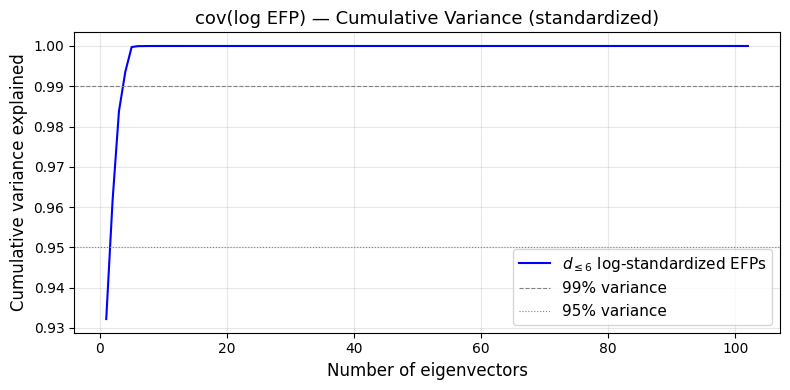

95% variance explained by 2 eigenvectors (out of 102)
99% variance explained by 4 eigenvectors (out of 102)


In [266]:
# Cumulative variance — log-standardized covariance (matches regression)
from sklearn.preprocessing import StandardScaler

X_cum = StandardScaler().fit_transform(np.vstack([efps_Z, efps_H]))
eigvals_cum = np.sort(np.clip(np.linalg.eigvalsh(np.cov(X_cum.T)), 0, None))[::-1]
cum_var = np.cumsum(eigvals_cum) / np.sum(eigvals_cum)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, 'b-', label=r'$d_{\leq 6}$ log-standardized EFPs')
ax.axhline(0.99, color='gray', linestyle='--', linewidth=0.8, label='99% variance')
ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8, label='95% variance')
ax.set_xlabel('Number of eigenvectors', fontsize=12)
ax.set_ylabel('Cumulative variance explained', fontsize=12)
ax.set_title('cov(log EFP) — Cumulative Variance (standardized)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

for thresh, label in [(0.95, '95%'), (0.99, '99%')]:
    n = np.searchsorted(cum_var, thresh) + 1
    print(f'{label} variance explained by {n} eigenvectors (out of {len(cum_var)})')